# GA vs. Random Node Selection

Compares genetic-algorithm accuracy vs. uniformly random subnetwork accuracy
for drug classification, as a function of subnetwork size.

Both methods use the same fixed-targets v7 simulated data (N=5000,
gamma=1.8, 10 drugs, 50 targets/drug, IC correlation=0.5).

- **GA**: best accuracy at final generation, averaged over 50 networks
- **Random**: mean accuracy over 10 random draws, averaged over 50 networks

## Config

In [1]:
import pathlib

# Add entries here as more N values become available.
GA_RESULTS = {
    5000: pathlib.Path('../../data/drug-fixed-targets-v7/N5000/ga-results-v7'),
    # 500:  pathlib.Path('../../data/drug-fixed-targets-v7/N500/ga-results-v7'),
}

RANDOM_RESULTS = {
    5000: pathlib.Path('../../data/drug-fixed-targets-v7/N5000/random-results-v7'),
    # 500:  pathlib.Path('../../data/drug-fixed-targets-v7/N500/random-results-v7'),
}

PLOT_OUT = pathlib.Path('../../plots/ga-vs-random-accuracy-vs-features.png')

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['text.usetex'] = False

## Load GA results

In [13]:
ga_dfs = []
for N, results_dir in GA_RESULTS.items():
    csvs = [f for f in sorted(results_dir.glob('*-full.csv')) if not f.name.startswith('combined')]
    if not csvs:
        print(f'WARNING: no GA CSVs found in {results_dir}')
        continue
    df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
    df['N'] = N
    ga_dfs.append(df)
    print(f'GA  N={N}: {len(csvs)} networks, {len(df)} rows, '
          f'feature sizes: {sorted(df["max_num_features"].unique())}')

ga_all = pd.concat(ga_dfs, ignore_index=True)

# Take the final-generation best accuracy for each (N, network, feature_size).
# Fill missing (network, feature_size) pairs with 1.0: a network that stopped
# early due to perfect accuracy never ran larger feature sizes — assume 1.0.
ga_final = (
    ga_all
    .sort_values('generation')
    .groupby(['N', 'original_network_idx', 'max_num_features'], as_index=False)
    .last()
)

ga_plot = (
    ga_final[['N', 'original_network_idx', 'max_num_features', 'best_accuracy']]
    .pivot(index=['N', 'original_network_idx'], columns='max_num_features', values='best_accuracy')
    .fillna(1.0)
    .stack()
    .reset_index(name='accuracy')
)
ga_plot = ga_plot[ga_plot['max_num_features'] <= ga_plot['N']]
ga_plot['method'] = 'Genetic'
print(f'GA plot rows: {len(ga_plot)}')

GA  N=5000: 50 networks, 6437 rows, feature sizes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(5000)]
GA plot rows: 700


## Load random selection results

In [14]:
rand_dfs = []
for N, results_dir in RANDOM_RESULTS.items():
    csvs = [f for f in sorted(results_dir.glob('*-full.csv')) if not f.name.startswith('combined')]
    if not csvs:
        print(f'WARNING: no random CSVs found in {results_dir}')
        continue
    df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
    df['N'] = N
    rand_dfs.append(df)
    print(f'Rand N={N}: {len(csvs)} networks, {len(df)} rows, '
          f'feature sizes: {sorted(df["max_num_features"].unique())}')

rand_plot = pd.concat(rand_dfs, ignore_index=True)[['N', 'original_network_idx', 'max_num_features', 'accuracy']]
rand_plot['method'] = 'Random'
print(f'Random plot rows: {len(rand_plot)}')

Rand N=5000: 50 networks, 7000 rows, feature sizes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(5000)]
Random plot rows: 7000


## Combine

In [15]:
plot_df = pd.concat([ga_plot, rand_plot], ignore_index=True)
plot_df.head()

,N,original_network_idx,max_num_features,accuracy,method
0,5000,0,1,0.181818,Genetic
1,5000,0,2,0.363636,Genetic
2,5000,0,4,0.818182,Genetic
3,5000,0,8,1.000000,Genetic
4,5000,0,16,1.000000,Genetic


## Plot: accuracy vs. number of sensor nodes

Saved to ../../plots/ga-vs-random-accuracy-vs-features.png


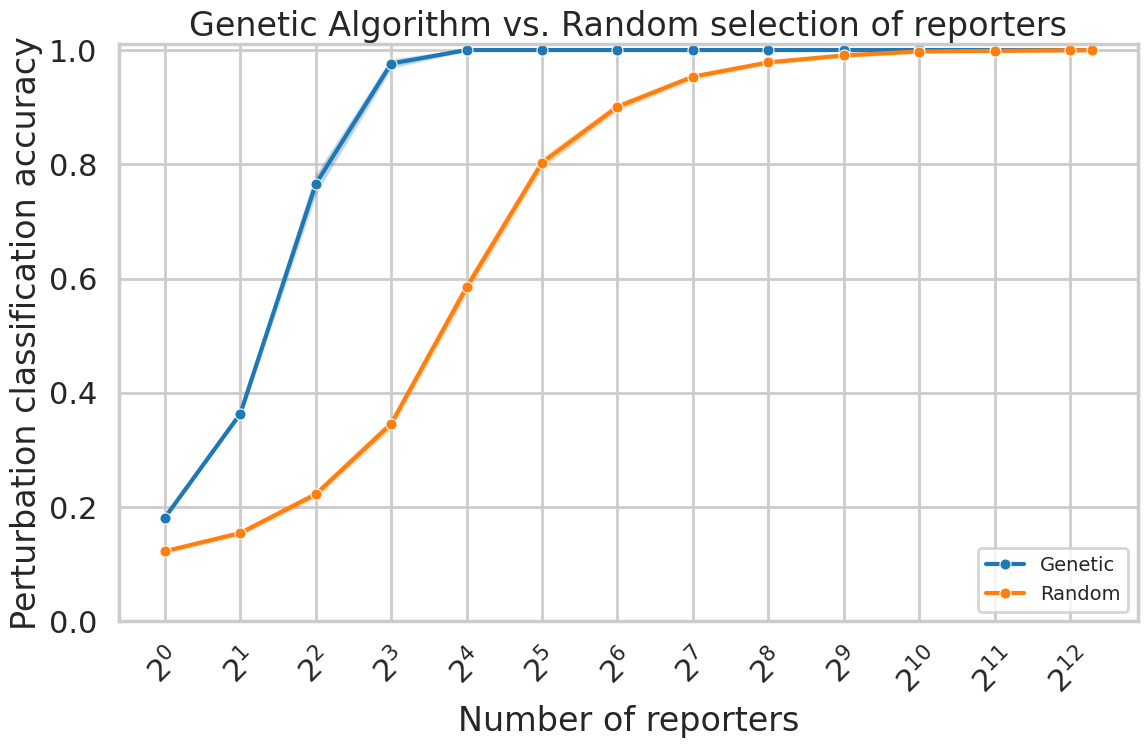

In [22]:
import matplotlib.ticker as mticker
# Assign color per N, linestyle per method.
Ns      = sorted(plot_df['N'].unique())
palette = dict(zip(Ns, sns.color_palette('tab10', n_colors=len(Ns))))
dashes  = {'Genetic': '', 'Random': (4, 2)}  # solid vs dashed

all_feature_sizes = sorted(plot_df['max_num_features'].unique())

with sns.plotting_context('poster', font_scale=1.0), sns.axes_style('whitegrid'):
    fig, ax = plt.subplots(figsize=(12, 8))

    # for N in Ns:
            # sub = plot_df[(plot_df['N'] == N) & (plot_df['method'] == method)]
     #        if sub.empty:
                 # continue
            # color = palette[N]
            # linestyle = '--' if method == 'Random' else '-'
            # label = f'N={N:,} {method}'
    sns.lineplot(
        data=plot_df[plot_df.N == 5_000],
        x='max_num_features',
        y='accuracy',
        ax=ax,
        # color=color,
        # linestyle=linestyle,
        lw=3,
        marker='o',
        markersize=8,
        hue='method',
        # label=label,
        errorbar='se',
    )

    ax.set_xscale('log', base=2)
    ax.set_xticks(2**np.arange(int(np.log2(max(all_feature_sizes))) + 1))
    # ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.get_xaxis().set_major_formatter(mticker.LogFormatterMathtext(base=2))
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel('Number of reporters')
    ax.set_ylabel('Perturbation classification accuracy')
    ax.set_title('Genetic Algorithm vs. Random selection of reporters')
    ax.legend(fontsize=14, loc='lower right')
    plt.tight_layout()

PLOT_OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_OUT, bbox_inches='tight', dpi=300)
print(f'Saved to {PLOT_OUT}')